<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/tensorflow_high_level_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def load_and_prepare_data(test_size: float = 0.2, val_size: float = 0.2, seed: int = 42):
    """
    Load California Housing, split into train/val/test, scale features using StandardScaler.

    Args:
        test_size: Fraction for test split (from full data).
        val_size: Fraction for validation split (from train portion).
        seed: Random seed.

    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test as np.float32 arrays.
    """
    data = fetch_california_housing()
    X = data.data
    y = data.target.reshape(-1, 1)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return (
        X_train.astype(np.float32),
        y_train.astype(np.float32),
        X_val.astype(np.float32),
        y_val.astype(np.float32),
        X_test.astype(np.float32),
        y_test.astype(np.float32),
    )


X_train, y_train, X_val, y_val, X_test, y_test = load_and_prepare_data()
input_size = X_train.shape[1]

Epoch 1/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.4786 - val_loss: 1.6865
Epoch 2/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7625 - val_loss: 0.7222
Epoch 3/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4839 - val_loss: 0.4483
Epoch 4/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4270 - val_loss: 0.4110
Epoch 5/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3901 - val_loss: 0.3893
Epoch 6/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3544 - val_loss: 0.3924
Epoch 7/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3414 - val_loss: 0.3677
Epoch 8/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3435 - val_loss: 0.3632
Epoch 9/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3370 - val_loss: 0.3589
Epoch 10/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3246 - val_loss: 0.3601
Epoch 11/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3206 - val_loss: 0.3524
Epoch 12/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3

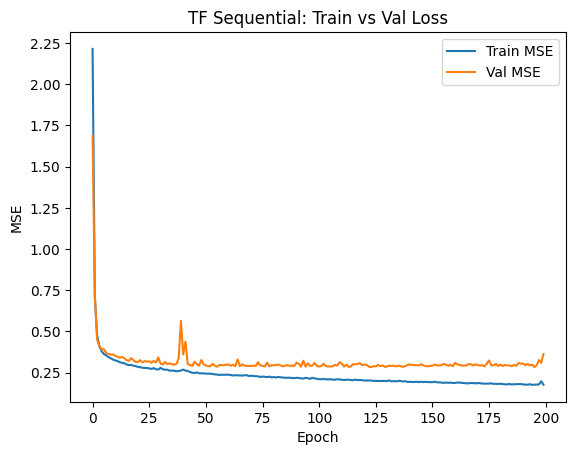

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt


def build_sequential_model(input_size: int) -> tf.keras.Model:
    """
    Build the deep regressor using TensorFlow Keras Sequential API.

    Args:
        input_size: Number of input features.
    Returns:
        tf.keras.Model instance (uncompiled here).
    """
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_size,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1),
    ])


model = build_sequential_model(input_size)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=256,
    verbose=1
)

test_mse = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", float(test_mse))

plt.plot(history.history["loss"], label="Train MSE")
plt.plot(history.history["val_loss"], label="Val MSE")
plt.title("TF Sequential: Train vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()